In [9]:
# Install the xlrd library to enable reading older Excel (.xls) files
!pip install openpyxl


------------------------------------------------------------
Timing Report for Set 1
------------------------------------------------------------
Processed shape: (150, 44)
Run 1: 0.0051 seconds
Run 2: 0.004817 seconds
Run 3: 0.004227 seconds
Run 4: 0.074924 seconds
Run 5: 0.010267 seconds

All times: [0.0051, 0.004817, 0.004227, 0.074924, 0.010267]
Best time   : 0.004227 seconds
Average time: 0.019867 seconds
Worst time  : 0.074924 seconds

Raw Predictions (first 30) - Set 1:
[ 1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
 -1  1  1  1  1  1]

Converted Predictions (first 30) - Set 1:
[0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0]

Anomaly Scores (first 10) - Set 1:
[ 0.099472  0.377887  0.312926 -0.067646  0.322399 -0.191323  0.523605
  0.396076  0.015586  0.215563]

Statistics (Predicted only):
Total students: 150
Predicted FAIL (at-risk): 37
Predicted PASS: 113
Failure %: 24.67 %

Confusion Matrix (pseudo labels) - Set 1:
[[105   0]
 [  8  3

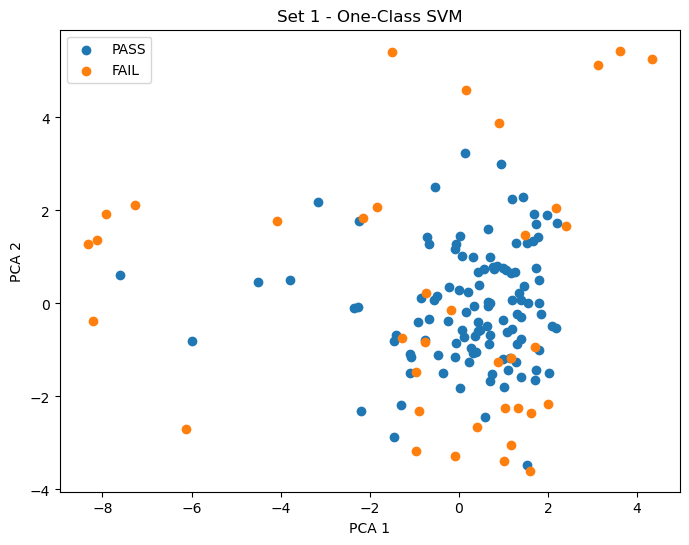


------------------------------------------------------------
Timing Report for Set 2
------------------------------------------------------------
Processed shape: (587, 44)
Run 1: 0.049704 seconds
Run 2: 0.062132 seconds
Run 3: 0.055154 seconds
Run 4: 0.027151 seconds
Run 5: 0.02944 seconds

All times: [0.049704, 0.062132, 0.055154, 0.027151, 0.02944]
Best time   : 0.027151 seconds
Average time: 0.044716 seconds
Worst time  : 0.062132 seconds

Raw Predictions (first 30) - Set 2:
[ 1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1]

Converted Predictions (first 30) - Set 2:
[0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]

Anomaly Scores (first 10) - Set 2:
[ 1.676407  0.971228 -0.271408  0.333691  0.733302  3.201485  3.024074
  3.47044   0.531935 -0.029709]

Statistics (Predicted only):
Total students: 587
Predicted FAIL (at-risk): 44
Predicted PASS: 543
Failure %: 7.5 %

Confusion Matrix (pseudo labels) - Set 2:
[[411   0]
 [132  4

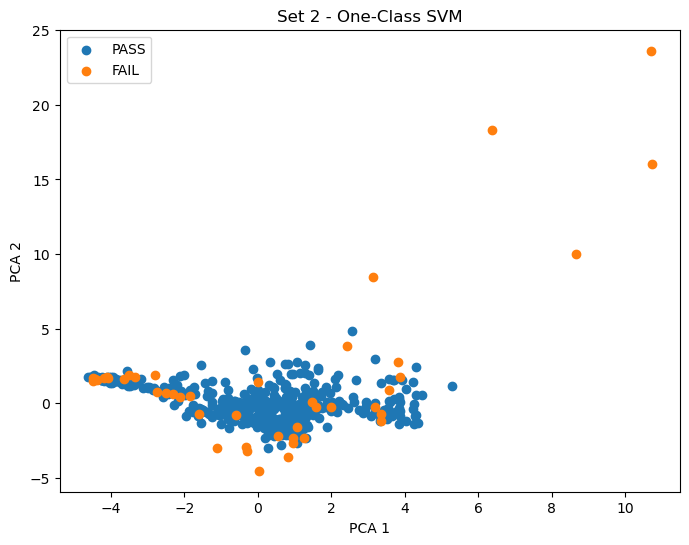


------------------------------------------------------------
Timing Report for Set 3
------------------------------------------------------------
Processed shape: (1582, 44)
Run 1: 0.265399 seconds
Run 2: 0.154939 seconds
Run 3: 0.19282 seconds
Run 4: 0.14732 seconds
Run 5: 0.298347 seconds

All times: [0.265399, 0.154939, 0.19282, 0.14732, 0.298347]
Best time   : 0.14732 seconds
Average time: 0.211765 seconds
Worst time  : 0.298347 seconds

Raw Predictions (first 30) - Set 3:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Converted Predictions (first 30) - Set 3:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Anomaly Scores (first 10) - Set 3:
[1.82759  2.916282 3.15369  1.50433  6.037903 2.234212 5.759271 7.014872
 0.320007 8.215839]

Statistics (Predicted only):
Total students: 1582
Predicted FAIL (at-risk): 93
Predicted PASS: 1489
Failure %: 5.88 %

Confusion Matrix (pseudo labels) - Set 3:
[[1107    0]
 [ 382   93]]

Classification Report (pseudo l

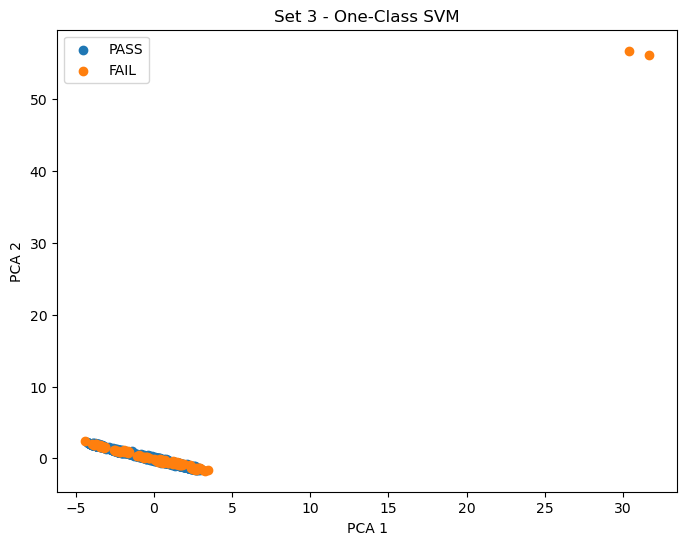

In [10]:
import os
import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA

# Base path
base_path = r"C:\Users\ariam\Desktop\OneDrive_1_3-5-2026"

folders = [
    "splits_example1",
    "splits_example2",
    "splits_example3"
]

def run_oneclass_svm_test(folder_path, test_name, repeat_times=5):
    print(f"\n{'-'*60}")
    print(f"Timing Report for {test_name}")
    print(f"{'-'*60}")

    # Load test data
    file_path = os.path.join(folder_path, "X_test.xls")
    try:
        X_test = pd.read_csv(file_path)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return

    # Load model and scaler
    model = joblib.load(os.path.join(folder_path, "oneclass_svm_model.pkl"))
    scaler = joblib.load(os.path.join(folder_path, "scaler.pkl"))

    # Align features
    expected_columns = list(scaler.feature_names_in_)
    for col in expected_columns:
        if col not in X_test.columns:
            X_test[col] = 0
    X_test = X_test[expected_columns]
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
    print("Processed shape:", X_test.shape)

    # Scale
    X_scaled = scaler.transform(X_test)

    # Repeat prediction multiple times for timing
    times = []
    for i in range(repeat_times):
        start = time.time()
        raw_pred = model.predict(X_scaled)
        scores = model.decision_function(X_scaled)
        end = time.time()
        elapsed = end - start
        times.append(elapsed)
        print(f"Run {i+1}: {round(elapsed,6)} seconds")

    # Summary timing
    print("\nAll times:", [round(t,6) for t in times])
    print("Best time   :", round(min(times),6), "seconds")
    print("Average time:", round(np.mean(times),6), "seconds")
    print("Worst time  :", round(max(times),6), "seconds")

    # Convert predictions: FAIL=-1 -> 1, PASS=1 -> 0
    pred = np.where(raw_pred == -1, 1, 0)

    # Show first few predictions and scores
    print(f"\nRaw Predictions (first 30) - {test_name}:")
    print(raw_pred[:30])
    print(f"\nConverted Predictions (first 30) - {test_name}:")
    print(pred[:30])
    print(f"\nAnomaly Scores (first 10) - {test_name}:")
    print(np.round(scores[:10],6))

    # Statistics based on predictions
    total_students = len(pred)
    failing_students = np.sum(pred)
    passing_students = total_students - failing_students
    print("\nStatistics (Predicted only):")
    print("Total students:", total_students)
    print("Predicted FAIL (at-risk):", failing_students)
    print("Predicted PASS:", passing_students)
    print("Failure %:", round((failing_students / total_students) * 100, 2), "%")

    # Pseudo labels for confusion matrix (unsupervised)
    threshold = np.percentile(scores, 30)  # Set the threshold at the 30th percentile of scores; students below this are labeled as FAIL
    y_true_pseudo = np.where(scores <= threshold, 1, 0)

    # Confusion matrix & classification report
    cm = confusion_matrix(y_true_pseudo, pred)
    cr = classification_report(y_true_pseudo, pred)
    print(f"\nConfusion Matrix (pseudo labels) - {test_name}:\n{cm}")
    print(f"\nClassification Report (pseudo labels) - {test_name}:\n{cr}")

    # Store results
    results = X_test.copy()
    results["score"] = scores
    results["prediction"] = pred

    # Best / Average / Worst cases
    best_case = results.sort_values(by="score", ascending=False).head(10)
    worst_case = results.sort_values(by="score", ascending=True).head(10)
    mid = len(results) // 2
    average_case = results.sort_values(by="score").iloc[max(0, mid-5):mid+5]

    print("\nBest Case (Top students):")
    print(best_case[["score","prediction"]])
    print("\nAverage Case:")
    print(average_case[["score","prediction"]])
    print("\nWorst Case (At-risk students):")
    print(worst_case[["score","prediction"]])

    # Save results
    safe_name = test_name.replace(" ","_")
    results.to_csv(f"{safe_name}_full_results.csv", index=False)
    best_case.to_csv(f"{safe_name}_best_case.csv", index=False)
    average_case.to_csv(f"{safe_name}_average_case.csv", index=False)
    worst_case.to_csv(f"{safe_name}_worst_case.csv", index=False)
    print("\nFiles saved successfully!")

    # PCA Visualization
    if X_scaled.shape[1] >= 2:
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X_scaled)
        plt.figure(figsize=(8,6))
        plt.scatter(X_2d[pred==0,0], X_2d[pred==0,1], label="PASS")
        plt.scatter(X_2d[pred==1,0], X_2d[pred==1,1], label="FAIL")
        plt.title(f"{test_name} - One-Class SVM")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.legend()
        plt.show()

    return results

# Run all examples
for i, folder in enumerate(folders,1):
    folder_path = os.path.join(base_path, folder)
    run_oneclass_svm_test(folder_path, f"Set {i}", repeat_times=5)